### Functions

In [222]:
import numpy as np
def x_eval(x,y,C,i): #Compute coefficients for Si(x) using Ci
    h=np.diff(x)
    Coeff=np.zeros(4)
    Coeff[2]=C[i]
    Coeff[0]=y[i]
    Coeff[1]=1/h[i]*(y[i+1]-y[i])-h[i]/3*(2*C[i]+C[i+1])
    Coeff[3]=(C[i+1]-C[i])/(3*h[i])
    return Coeff
def spline(t,x,Coeff,i): #Evaluate Spline
    y=Coeff[0]+Coeff[1]*(t-x[i])+Coeff[2]*((t-x[i])**2)+Coeff[3]*((t-x[i])**3)
    return y
def setup_tridiagonal_matrix(x, y): #Setup Tridiagonal Matrix
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 3) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 3) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1,n-2):
        A[i - 1] = h[i] # Subdiagonal
        C[i - 1] = h[i] # Superdiagonal
    for i in range(1, n - 1):
        B[i - 1] = 2*(h[i-1]+h[i]) # Main diagonal
        D[i - 1] = 3/h[i]*(y[i+1]-y[i])-3/h[i-1]*(y[i]-y[i-1]) #rhs
    return A, B, C, D
def thomas_algorithm(a, b, c, d): #Thomas Algoritm
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

### Setup Tridiagonal

In [223]:
# Example data points
x = np.sort(np.random.uniform(0,10,10))
y = np.random.uniform(0,25,10)
n=x.size-1
# Set up the tridiagonal matrix for the cubic spline
A, B, C1, D = setup_tridiagonal_matrix(x, y)
print("Subdiagonal (A):", A)
print("Main diagonal (B):", B)
print("Superdiagonal (C):", C1)
print("Right-hand side (D):", D)
print(np.diff(x))


Subdiagonal (A): [2.7622265  0.2667744  0.35093303 0.19002242 0.78087947 3.01202429
 0.24153144]
Main diagonal (B): [8.45538136 6.0580018  1.23541487 1.08191091 1.94180378 7.58580752
 6.50711145 1.05065123]
Superdiagonal (C): [2.7622265  0.2667744  0.35093303 0.19002242 0.78087947 3.01202429
 0.24153144]
Right-hand side (D): [ 33.60478601 -31.0600446   58.59929505 -23.39874976 -83.47344405
  66.36540304 -20.16347114 275.31027767]
[1.46546418 2.7622265  0.2667744  0.35093303 0.19002242 0.78087947
 3.01202429 0.24153144 0.28379418]


### Use Thomas Algorithm to solve for Ci

In [224]:
C=np.zeros(x.size)
C[1:x.size-1] = thomas_algorithm(A, B, C1, D) 
print("Second Derivatives:", C)


Second Derivatives: [  0.           7.63499977 -11.20547094  58.97537311 -32.11559978
 -49.19913471  23.26134364 -23.79531882 267.50798703   0.        ]


### Evaluate Spline

In [225]:
poly_eval=np.zeros(np.int64(x[-1]*100+1-(x[0]*100)))
poly_x=np.linspace(x[0],x[-1],np.int64(x[-1]*100+1-(x[0]*100)))
for i in range (0,n):
    Coeff=x_eval(x,y,C,i)
    print(Coeff)
    t=poly_x[np.int64(x[i]*100-(x[0]*100)):np.int64(x[i+1]*100+1)]
    poly_y=spline(t,x,Coeff,i)
    poly_eval[np.int64(x[i]*100-(x[0]*100)):np.int64(x[i+1]*100+1)]=poly_y  

[ 24.10651104 -11.76208767   0.           1.73665106]
[12.33519721 -0.57326898  7.63499977 -2.27358506]
[ 21.08900758 -10.43571904 -11.20547094  87.69062811]
[ 19.17243779   2.30806795  58.97537311 -86.52265463]
[ 23.50606211  11.73404967 -32.11559978 -29.9675777 ]
[ 24.37052745  -3.71757297 -49.19913471  30.93114074]
[  6.19540118 -23.9718615   23.26134364  -5.20764531]
[  2.72133374 -25.58020769 -23.79531882 402.02262429]
[   0.81938077   33.28406315  267.50798703 -314.20422265]


### Plot Spline

Text(0, 0.5, 'Y')

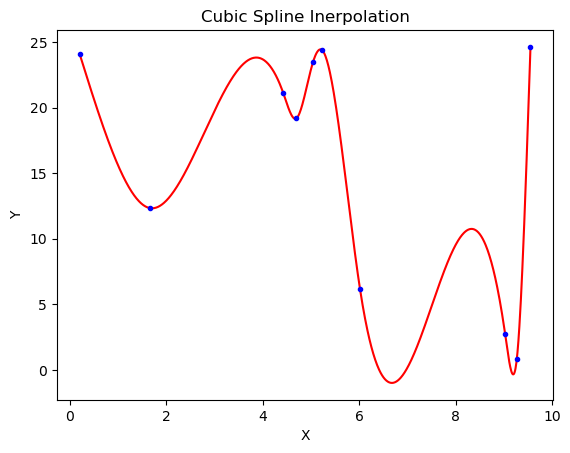

In [226]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(poly_x,poly_eval,'r')
plt.plot(x,y,'b.')
plt.title("Cubic Spline Inerpolation")
plt.xlabel("X")
plt.ylabel("Y")